In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!find /content/drive/MyDrive -name "CSE422_project_Rifat.ipynb"

/content/drive/MyDrive/CSE422_project/CSE422_project_Rifat.ipynb


In [25]:
!pip install -q import-ipynb

In [26]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/CSE422_project')

In [33]:
!pip install -q nbformat

In [35]:
import nbformat

path = "/content/drive/MyDrive/CSE422_project/CSE422_project_Rifat.ipynb"

with open(path, "r", encoding="utf-8") as f:
    notebook = nbformat.read(f, as_version=4)

print("Number of cells:", len(notebook.cells))

Number of cells: 20


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 All libraries imported successfully.
Shape: 119,390 rows × 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


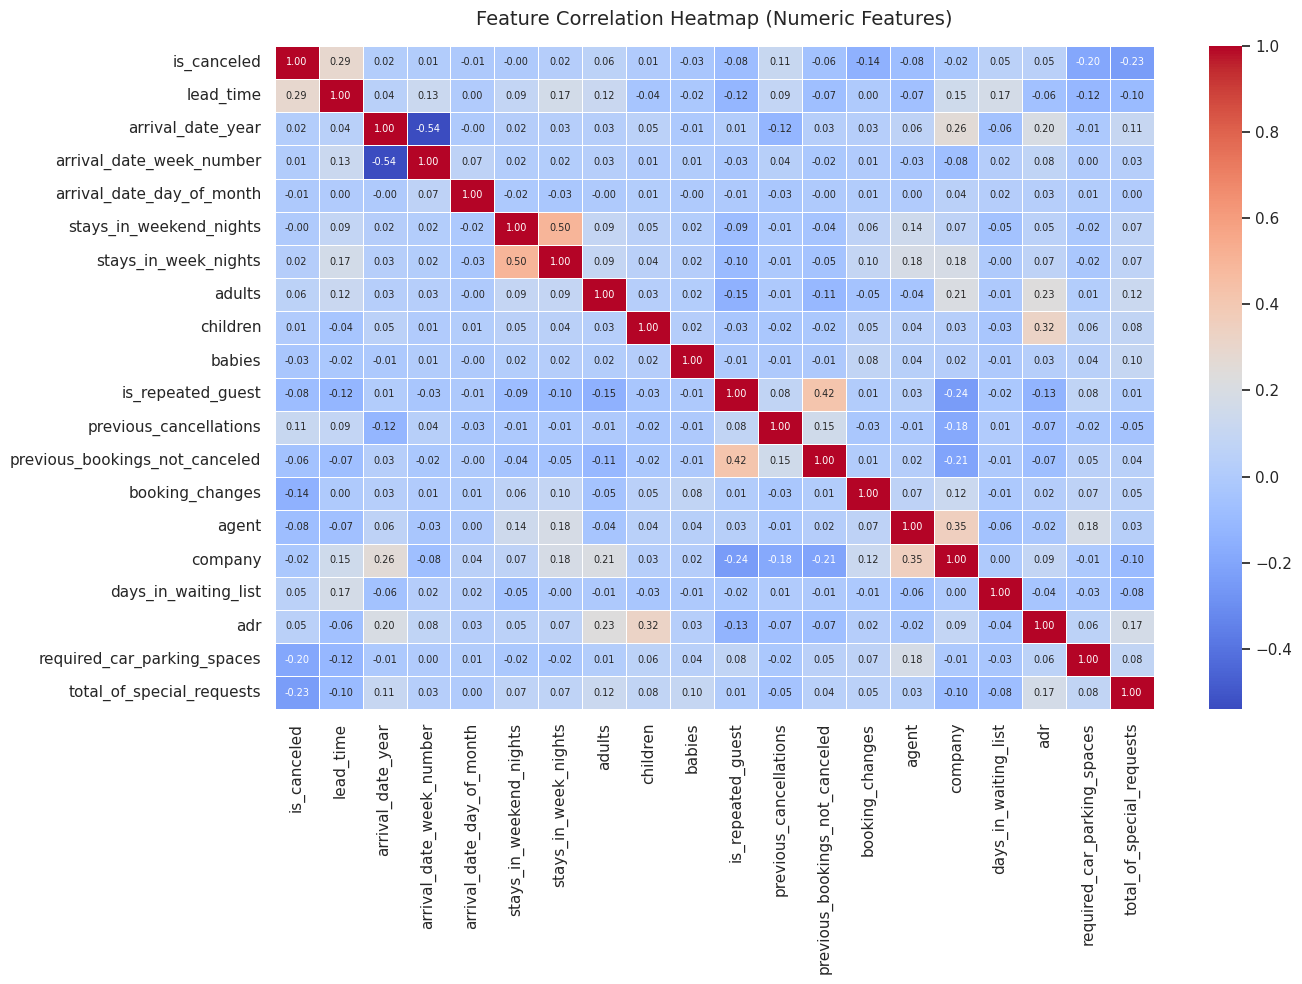

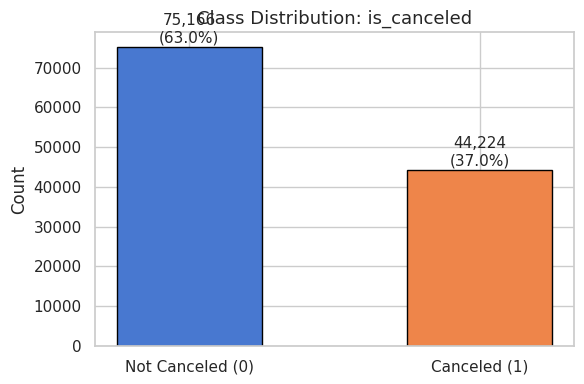

Class 0 (Not Canceled): 75,166 (63.0%)
Class 1 (Canceled)    : 44,224 (37.0%)
→ Dataset is moderately imbalanced (63% / 37%). Stratified split will be used.


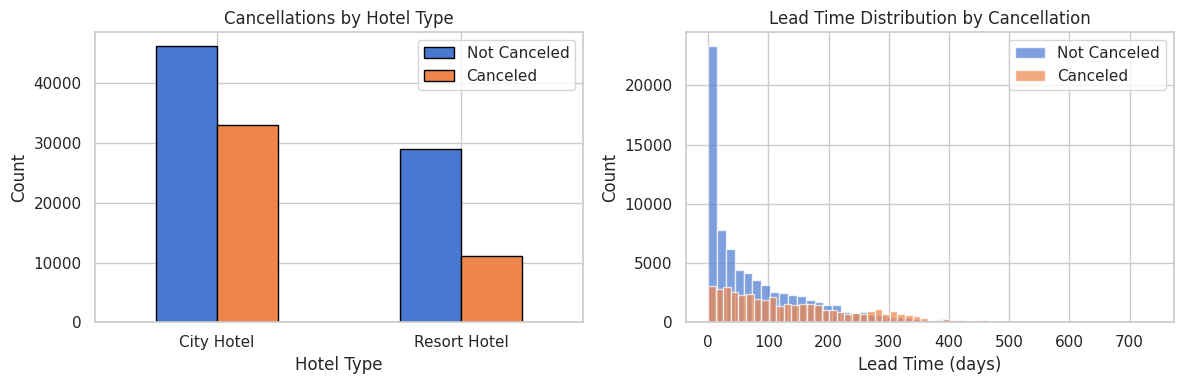

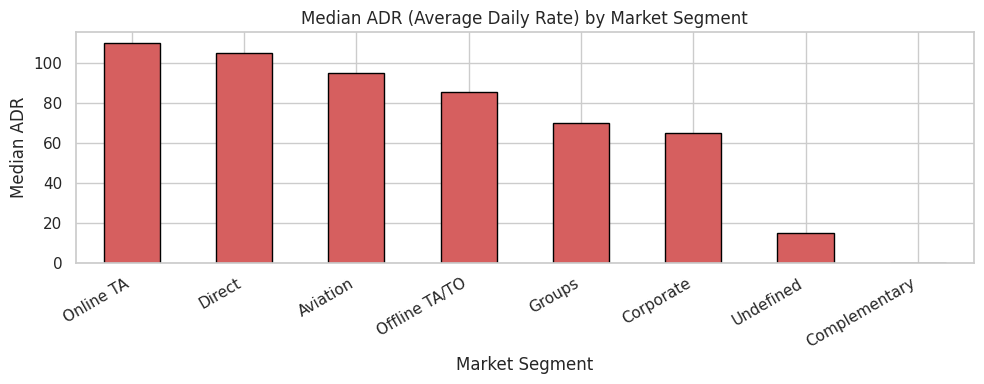

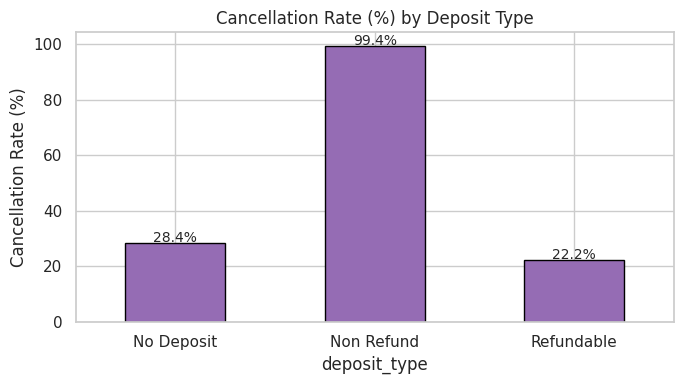

✔ Dropped leaking columns.
Null counts before fix:
children         4
country        488
agent        16340
company     112593

Nulls after fix: 0

Categorical columns encoded: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
✔ Label Encoding complete.

Feature matrix shape: (119390, 28)
Target distribution:
is_canceled
0    75166
1    44224


In [36]:
from IPython import get_ipython

for cell in notebook.cells:
    if cell.cell_type == "code":
        get_ipython().run_cell(cell.source)

Train/Test Split (Stratified 80/20)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} samples | Test: {X_test.shape[0]:,} samples")
print(f"Train class balance: {dict(y_train.value_counts().items())}")
print(f"Test  class balance: {dict(y_test.value_counts().items())}")

# ── Scaling ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\n✔ StandardScaler fitted on train, applied to test.")


Train: 95,512 samples | Test: 23,878 samples
Train class balance: {0: 60133, 1: 35379}
Test  class balance: {0: 15033, 1: 8845}

✔ StandardScaler fitted on train, applied to test.


Model Training & Evaluation

In [39]:
results = {}

def evaluate(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    probs = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else preds.astype(float)
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    auc  = roc_auc_score(y_test, probs)
    cm   = confusion_matrix(y_test, preds)
    fpr, tpr, _ = roc_curve(y_test, probs)
    results[name] = dict(acc=acc, prec=prec, rec=rec, auc=auc,
                         cm=cm, fpr=fpr, tpr=tpr, preds=preds)
    print(f"  [{name:<20}]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  AUC={auc:.4f}")
    return model

print("Training models — this may take a few minutes...\n")
knn = evaluate("KNN",                KNeighborsClassifier(n_neighbors=7, n_jobs=-1),   X_train_sc, X_test_sc)
dt  = evaluate("Decision Tree",      DecisionTreeClassifier(max_depth=10, random_state=42), X_train.values, X_test.values)
lr  = evaluate("Logistic Regression",LogisticRegression(max_iter=500, random_state=42), X_train_sc, X_test_sc)
nb  = evaluate("Naive Bayes",        GaussianNB(),                                      X_train.values, X_test.values)
mlp = evaluate("Neural Network",     MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                      max_iter=200, random_state=42,
                                      early_stopping=True, validation_fraction=0.1),    X_train_sc, X_test_sc)
print("\n All supervised models trained.")


Training models — this may take a few minutes...

  [KNN                 ]  Acc=0.8330  Prec=0.7912  Rec=0.7460  AUC=0.9046
  [Decision Tree       ]  Acc=0.8404  Prec=0.8248  Rec=0.7228  AUC=0.9185
  [Logistic Regression ]  Acc=0.7933  Prec=0.8045  Rec=0.5838  AUC=0.8637
  [Naive Bayes         ]  Acc=0.5709  Prec=0.4597  Rec=0.9034  AUC=0.8013
  [Neural Network      ]  Acc=0.8559  Prec=0.8201  Rec=0.7826  AUC=0.9345

 All supervised models trained.


K-Means Clustering (Unsupervised)

Training K-Means (k=2)...
  [K-Means]  Acc=0.6296  Prec=0.0000  Rec=0.0000


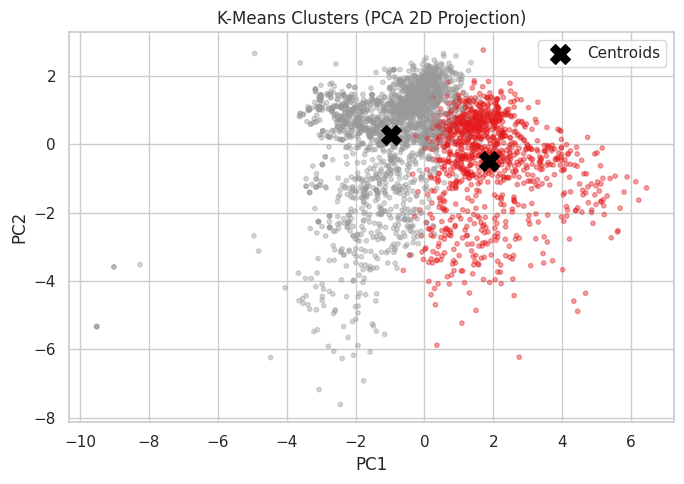

In [40]:
print("Training K-Means (k=2)...")
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(X_train_sc)
km_labels = km.predict(X_test_sc)

# Align cluster labels with true labels
aligned = np.zeros_like(km_labels)
for cluster in range(2):
    mask = km_labels == cluster
    if mask.sum() > 0:
        m = mode(y_test.values[mask], keepdims=True)[0][0]
        aligned[mask] = m

km_acc  = accuracy_score(y_test, aligned)
km_prec = precision_score(y_test, aligned, zero_division=0)
km_rec  = recall_score(y_test, aligned, zero_division=0)
print(f"  [K-Means]  Acc={km_acc:.4f}  Prec={km_prec:.4f}  Rec={km_rec:.4f}")

# ── PCA cluster visualisation ──
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test_sc[:3000])
km_vis = km.predict(X_test_sc[:3000])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=km_vis, cmap="Set1", alpha=0.4, s=10)
centers_pca = pca.transform(km.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c="black", marker="X", s=200, label="Centroids", zorder=5)
ax.set_title("K-Means Clusters (PCA 2D Projection)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()


Model Comparison & Evaluation Plots

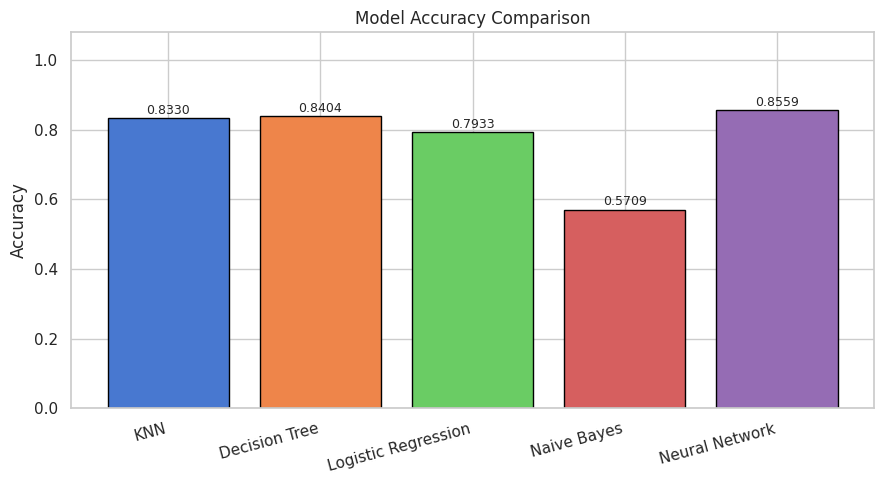

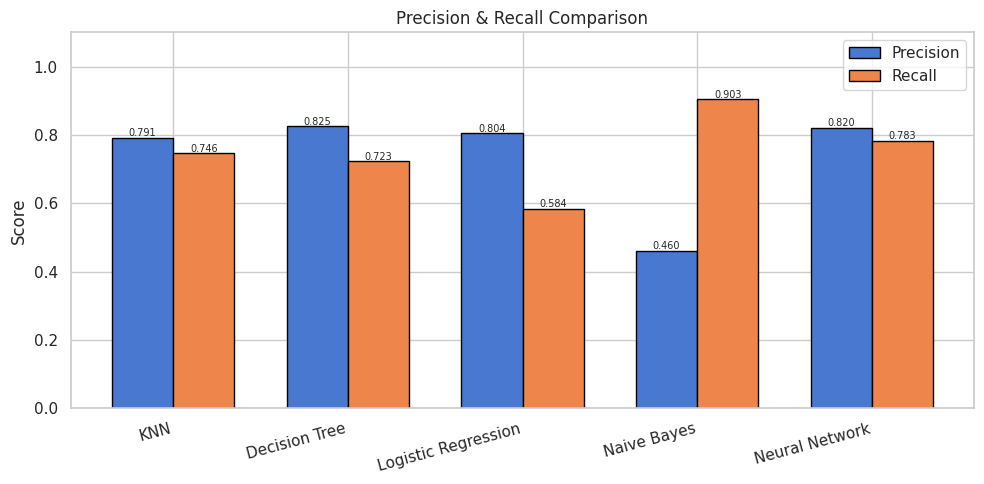

In [41]:
model_names = list(results.keys())
accs  = [results[m]["acc"]  for m in model_names]
precs = [results[m]["prec"] for m in model_names]
recs  = [results[m]["rec"]  for m in model_names]
aucs  = [results[m]["auc"]  for m in model_names]

# ── Accuracy bar chart ──
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, accs, color=COLORS[:len(model_names)], edgecolor="black")
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.08); ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison")
ax.set_xticklabels(model_names, rotation=15, ha="right")
plt.tight_layout(); plt.show()

# ── Precision & Recall grouped bar ──
x = np.arange(len(model_names)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, precs, w, label="Precision", color=COLORS[0], edgecolor="black")
b2 = ax.bar(x + w/2, recs,  w, label="Recall",    color=COLORS[1], edgecolor="black")
for b, v in zip(b1, precs): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.3f}", ha="center", fontsize=7)
for b, v in zip(b2, recs):  ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.3f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0, 1.1); ax.set_ylabel("Score"); ax.set_title("Precision & Recall Comparison"); ax.legend()
plt.tight_layout(); plt.show()

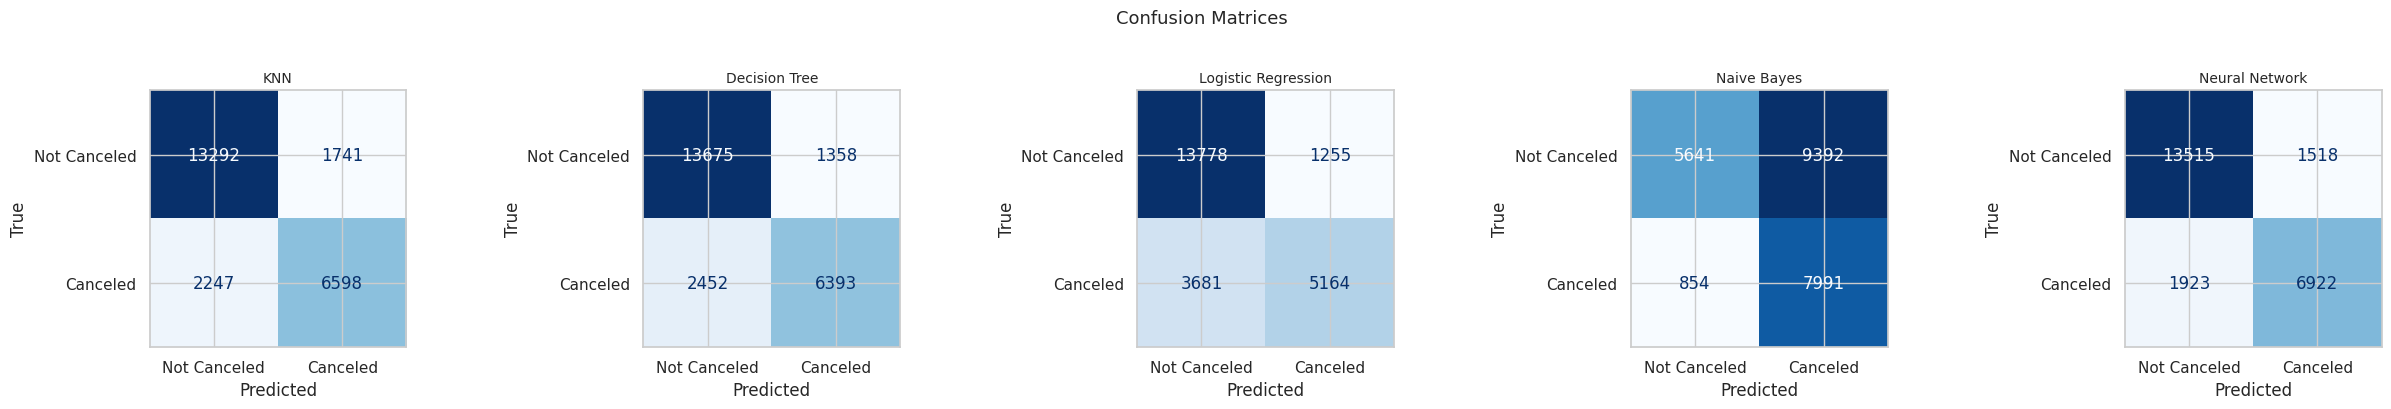

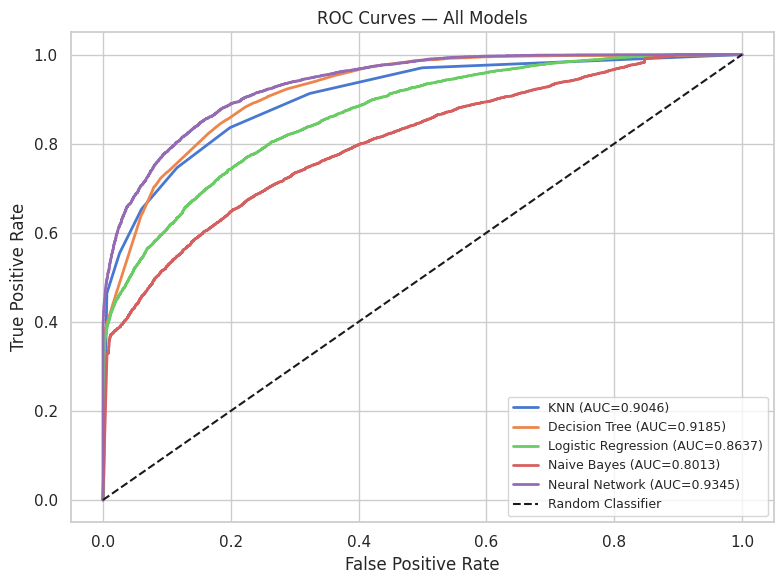

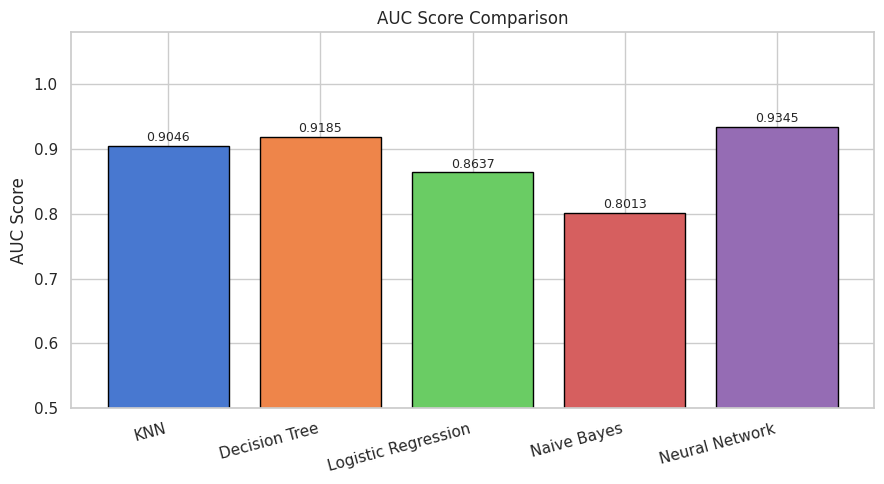

In [42]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, len(model_names), figsize=(5*len(model_names), 4))
for ax, name in zip(axes, model_names):
    ConfusionMatrixDisplay(results[name]["cm"],
        display_labels=["Not Canceled", "Canceled"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── ROC Curves ──
fig, ax = plt.subplots(figsize=(8, 6))
for i, name in enumerate(model_names):
    ax.plot(results[name]["fpr"], results[name]["tpr"],
            label=f"{name} (AUC={results[name]['auc']:.4f})", color=COLORS[i], lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models"); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

# ── AUC Bar Chart ──
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, aucs, color=COLORS[:len(model_names)], edgecolor="black")
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0.5, 1.08); ax.set_ylabel("AUC Score")
ax.set_title("AUC Score Comparison"); ax.set_xticklabels(model_names, rotation=15, ha="right")
plt.tight_layout(); plt.show()


Final Results Summary

In [43]:
summary = pd.DataFrame({
    "Model":     model_names,
    "Accuracy":  accs,
    "Precision": precs,
    "Recall":    recs,
    "AUC":       aucs
}).set_index("Model").round(4)

display(summary.style.highlight_max(color="lightgreen").format("{:.4f}"))

best     = max(results, key=lambda m: results[m]["acc"])
best_auc = max(results, key=lambda m: results[m]["auc"])
print(f"\n Best Model by Accuracy : {best} ({results[best]['acc']:.4f})")
print(f" Best Model by AUC      : {best_auc} ({results[best_auc]['auc']:.4f})")


,Accuracy,Precision,Recall,AUC
Model,,,,
KNN,0.8330,0.7912,0.7460,0.9046
Decision Tree,0.8404,0.8248,0.7228,0.9185
Logistic Regression,0.7933,0.8045,0.5838,0.8637
Naive Bayes,0.5709,0.4597,0.9034,0.8013
Neural Network,0.8559,0.8201,0.7826,0.9345



 Best Model by Accuracy : Neural Network (0.8559)
 Best Model by AUC      : Neural Network (0.9345)
